In [6]:
#Correlation - Pearson vs Spearman and df.corr()

#Correlation measures whether two numeric columns tend to move together-
# as one goes up and does the other tend to go up too (positive),
# as one goes up and does the other tend to go down (negative),
#pr show no pattern at all.
#it ranges from -1(perfectly opposite) to +1(perfectly together)
#with 0 meaning no linear relationship

#Both Pearson and Spearman give you a number between -1 and +1

In [7]:
#Pearson --> measures a straight-line relationship, using actual numbers

#Pearson asks do the two things change together by consistent amounts

#ATHLETE            TRAINING HOURS          RACETIME
#   A                      2                   30
#   B                      4                   27
#   C                      6                   24
#   D                      8                   21
#   E                      10                  18

#Here everytime training hours go up, race time goes down, by the same amount, every single time.
#This is a perfect relationship but in the opposite direction

#Pearson checks if the pattern is a steady, equal sized change
import pandas as pd
training = pd.Series([2,4,6,8,10])
race_time = pd.Series([30,27,24,21,18])
print(training.corr(race_time,method='pearson'))

#Here every +2 in the training hours matches exactly - in race time. Perfectly steady and consistent
#Pearson would give this a score of exactly - (perfect opposite relationship)

-1.0


In [8]:
training = pd.Series([2,4,6,8,10])
race_time2 = pd.Series([30,26,23,15,12])
print(round(training.corr(race_time2,method='pearson'),4))
print(round(training.corr(race_time2,method='spearman'),4))

-0.9869
-1.0


In [9]:
#Spearman doesn't look at the actual numbers at all
#It only asks if i lined these Athletes from least to most training hours,
#Does race_time also line up perfectly from most to least in the same order
#Here Athlete A has the least training and the slowest time and Athlete E has most training and fastest time and Everyone in between follows the exact right order
#So spearman gives it a perfect score, Bcz order is all it cares about not by how much

training = pd.Series([2,4,6,8,10])
race_time = pd.Series([30,27,24,21,18])
print(training.rank())
print(race_time2.rank())

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
dtype: float64
0    5.0
1    4.0
2    3.0
3    2.0
4    1.0
dtype: float64


In [10]:
import pandas as pd
df=pd.read_csv("Datasets/all_athlete_games.csv", low_memory=False)

In [11]:
print(df[['Age','Year']].corr(method='spearman')) #Depends on Rank based on the how we sorted values That's why it is showing the Positive values in the output
print(df[['Age','Year']].corr(method='pearson')) #Depends on Exact Values That's why it is showing the Negative values in the output

           Age      Year
Age   1.000000  0.039296
Year  0.039296  1.000000
           Age      Year
Age   1.000000 -0.080696
Year -0.080696  1.000000


In [12]:
#Have gymnasts gotten older over time due to rule changes?

df.groupby('Sport')['Age'].corr
gymnastics=df[df['Sport']=='Gymnastics']
print(round(gymnastics['Age'].corr(gymnastics['Year'],method='spearman'),4))

#a moderate negative relationship

-0.3657


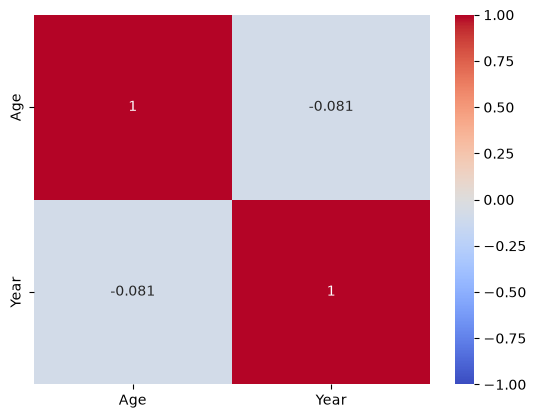

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix=df[['Age','Year']].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0,vmin=-1,vmax=1)
plt.show()

Axes(0.125,0.11;0.775x0.77)
1.6945073153637351


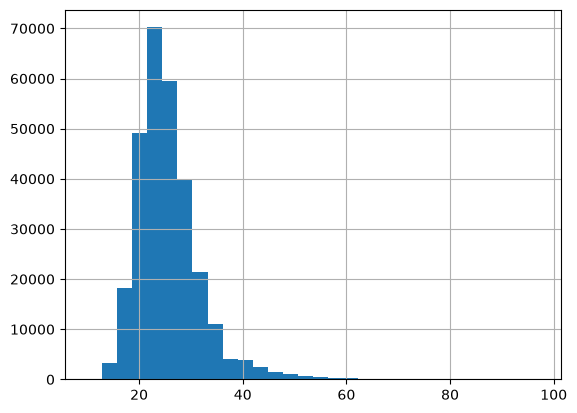

In [14]:
#Distribution shapes - Normal, Skewed, Kurtosis

#Normal distribution - the symmetric baseline

#A normal distribution (bell-curve) distribution is symmetric: the mean, median and the "typical" value all sit roughly in the same place and values taper off evenly on both sides
age=df['Age']
print(age.hist(bins=30))
print(age.skew())

#skew ~0 --> roughly symmetric (normal)
#skew >0 --> right skewed (a long tail stretching towards higher values)
#skew <0 --> left-skewed (a long tail stretching towards lower values)

#1.69 skew means it is solid right skew

In [19]:
#Every Numeric Column has a shape if you plot,
#In a histogram --> values are along the bottom in a continuous range
#Height shows how common each value is

#Distribution is just describing what that histogram looks like
#is it symmetric?
#is it lopsided?
#are extreme values common or rare?

#Normal distribution --"bell curve"
#Here most values cluster around the middle, and it tapers off evenly on both sides
#Symmetric means if you folded the histogram in half the two sides would roughly match

25.048863283495525
25.04227027048377


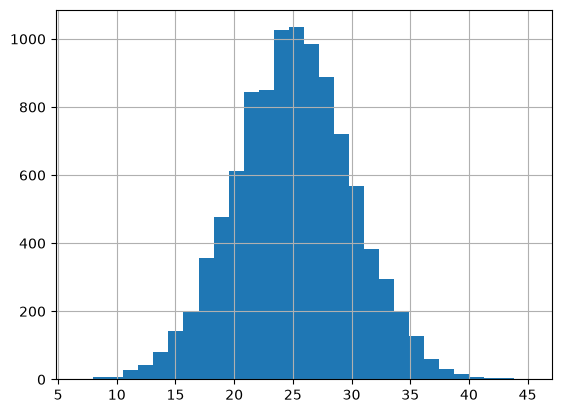

In [22]:
#Normal distribution (bell curves)

import numpy as np
np.random.seed(1)
normal=pd.Series(np.random.normal(loc=25,scale=5,size=10000))
normal.hist(bins=30)

#this generates random or fake 10000 values centered around 25 with a std of 5

#Here mean ~ median
print(normal.mean())
print(normal.median())

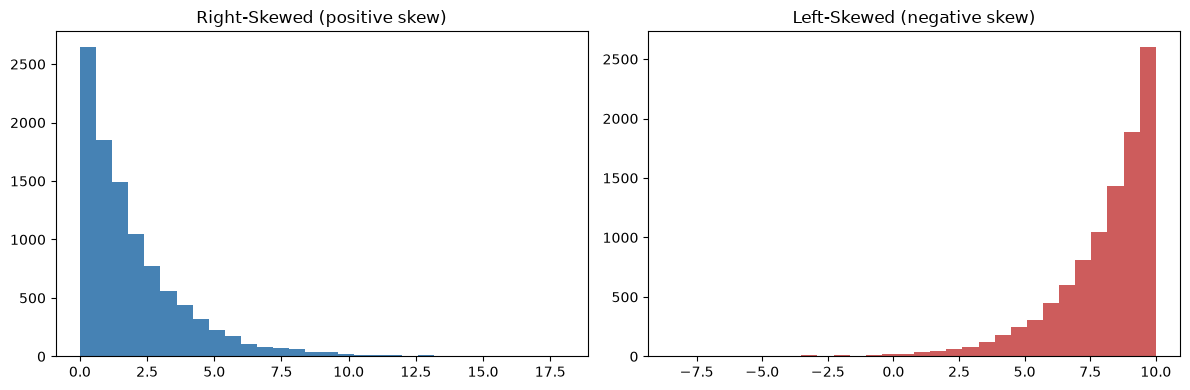

In [18]:
#skewness --> measuring which direction a distribution leans
import matplotlib.pyplot as plt
np.random.seed(1)
right_skewed_example = np.random.exponential(scale=2, size=10000)     # long tail to the RIGHT
left_skewed_example = 10 - np.random.exponential(scale=2, size=10000)  # long tail to the LEFT

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(right_skewed_example, bins=30, color='steelblue')
axes[0].set_title('Right-Skewed (positive skew)')
axes[1].hist(left_skewed_example, bins=30, color='indianred')
axes[1].set_title('Left-Skewed (negative skew)')
plt.tight_layout()
plt.show()

In [23]:
#kurtosis --> measuring how heavy the tails aiter

#Skewness tells you which direction a distribution leans.
#Kurtosis tells you how likely are extreme values
#compared to what a normal distribution would predict

#Two distributions can be both perfectly symmetric (skew~0) and still look very different - one might have almost no extreme outliers.
#while another has surprisingly many, even while both are centered and shaped similarly in the middle

#The reference point: normal distribution~0
print(normal.kurt())
#close to 0 since normal was constructed to actually be normal
#Its kurtosis landed near the reference point.

#The reading scale for kurtosis value:
#~0 - Tails behave like a normal distribution
#>0 (positive,"leptokurtic")-Heavier tails - extreme values happen more often than a normal distribution predicts
#<0 (negative,"platykurtic")-Lighter tails - extreme values happen less often than a normal distribution predicts

print(age.kurt())

#A large positive number - age has heavier tails than a normal bell curve would predict
#Genuienly extreme ages, very young teenagers and competitors in their 70s-90s show up more often in this dataset than you'd expect if ages were distributed in a plain well-behaved bell curve

0.02928411766794703
6.06506954059187


In [ ]:
#Hypothesis Testing

#What a p-value means

#Foe example if in this dataset
#Gold medalists have an average age of 25.96 while Non medalists have an average age of 25.61

#Is this a genuine pattern in the world, or could it just be random luck - the particular group of athletes who happened to end up in this dataset

#So if you had a totally different, equally sized sample of olympic athletes would you expect to see roughly the same gap again? or could this gap easily been produced by pure chance even if there is no real differrence between medalists and non-medalists?

#A hypothesis test is formal, repeatable procedure for answering that question
#With a number, instead of just guessing based on a gut feeling

In [24]:
#Hypothesis testing - two competing hypothesis

#Every hypothesis test starts by writing down two opposite claims,

#Null hypothesis(H0):"There is no real difference - any gap we see is just due to random chance/sampling"
#Alternative hypothesis (H1):"There is real difference"

#The test doesn't prove the alternative hypothesis is true
#Instead it works backwards-it assumes null hypothesis is true and then checks how surprisingly your actual observed data would be under that assumption

In [26]:
from scipy import stats
gold_age=df[df['Medal']=='Gold']['Age'].dropna()
no_medal_age=df[df['Medal'].isna()]['Age'].dropna()

print(gold_age.mean(),no_medal_age.mean())


25.9624215630348 25.605030522453486


In [31]:
t_stat,p_value=stats.ttest_ind(gold_age,no_medal_age,equal_var=False)
print(t_stat,p_value)

#stats.ttest_ind() runs an independent samples t-test — a standard test for comparing the means of two separate groups. 
# It hands back two numbers:
# 1. t_stat — a measure of how big the difference is, relative to how much natural variation exists within each group.
# 2. p_value — the actual number we care about for the decision

6.988284843747572 2.892566614200782e-12


In [ ]:
#How to read the p-value

#p=2.89e-12
#The probability of randomly drawing samples that shows a gap this large (25.96 vs 25.61) purely by chance is about p value   (2.89e-12)-essentially impossible

#Because the probability is so small we conclude null hypothesis is likely false
#There is probably a genuine differrence in age between medalists and non-medalists

In [ ]:
#Comparing to alpha

alpha=0.05 #the cutoff

if p_value<alpha:
    print("Reject the null hypothesis-evidence of a real difference")
else:
    print("Failed to reject the null hypothesis--not enough evidence of a real difference")

# 0.05 is the traditional, widely-used cutoff — read as "we're willing to accept roughly a 1-in-20 risk of being wrong when we call something significant." It's a convention, not a law of nature — some fields use stricter cutoffs (like 0.01) for higher-stakes conclusions, but 0.05 is the default almost everyone starts with.
# Since 2.89e-12 < 0.05 by an enormous margin, we'd "reject the null hypothesis" here.

Reject the null hypothesis-evidence of a real difference


In [ ]:
male_age = df[df['Gender'] == 'Male']['Age'].dropna()
female_age = df[df['Gender'] == 'Female']['Age'].dropna()

t_stat3, p_value3 = stats.ttest_ind(male_age, female_age, equal_var=False)
print(male_age.mean(), female_age.mean())   # 26.34, 24.10
print(t_stat3, p_value3)                      # extremely large t, p ≈ 0.0

# The p-value here is essentially zero — an extremely "significant" result. 
# But look at the actual difference: 26.34 vs 24.10 — about 2.2 years. Real, and worth noting, but nowhere near dramatic.
# Always report the actual size of the difference alongside the p-value --> the p-value alone only tells you "is this probably real," never "does this actually matter in practice."

26.33600919142333 24.098607447678503
91.79941854024766 0.0


In [ ]:
#Summarized checklist

#1. State the null hypothesis
#2. State the alternative
#3. Run the test- get a p-value
#4. Compared to alpha (usually 0.05)-decide whether to reject null or not
#5. Also check the actual size of the difference